In [2]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

In [5]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('ggplot')

import tensorflow as tf

%matplotlib inline

In [4]:
n_samples = 50
train_X = np.linspace(1, 50, n_samples)
train_Y = 10*train_X + 6 +40*np.random.randn(50)
train_Y = train_Y.reshape(n_samples, 1)
train_X = train_X.reshape(n_samples, 1)

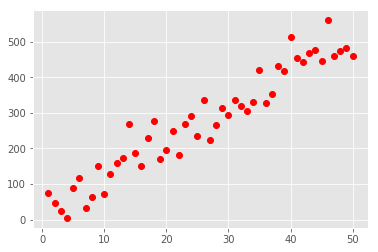

In [6]:
plt.plot(train_X, train_Y, 'ro')

In [7]:
# Model linear regression y = Wx + b. x is of shape `num_samples, 1`
x = tf.placeholder(tf.float32, [None, 1])

# Here we initialize W and b to be negative just to illustrate our point!
W = tf.Variable(-100*tf.ones([1, 1]))
b = tf.Variable(-100*tf.ones([1]))

product = tf.matmul(x,W)
y = product + b

In [8]:
clip_W = W.assign(tf.maximum(0., W))
clip_b = b.assign(tf.maximum(0., b))
clip = tf.group(clip_W, clip_b)

In [9]:
y_ = tf.placeholder(tf.float32, [None, 1])

# Cost function 
cost = tf.reduce_sum(tf.pow(y-y_, 2))/(2*n_samples)

In [10]:
lr = 0.001
steps = 10
# Training using Gradient Descent to minimize cost
train_step = tf.train.GradientDescentOptimizer(lr).minimize(cost)

init = tf.global_variables_initializer()

In [11]:
with tf.Session() as sess:
    sess.run(init)
    for i in range(steps):
        print("*"*40)
        print("Iteration Number %d" %i)
        print("*"*40)
        print("\nBefore gradient computation")
        print("-"*40)
    
        print("W: %f" % sess.run(W))
        print("b: %f" % sess.run(b))
        feed = { x: train_X, y_: train_Y }
        sess.run(train_step, feed_dict=feed)
        print("\nAfter gradient computation")
        print("-"*40)
        print("W: %f" % sess.run(W))
        print("b: %f" % sess.run(b))
        print("\nAfter gradient projection")
        print("-"*40)
        # THIS line would ensure the projection step happens!
        sess.run(clip)
        print("W: %f" % sess.run(W))
        print("b: %f" % sess.run(b))
        print("\nCost: %f" % sess.run(cost, feed_dict=feed))
        print("*"*40)
    learnt_W = sess.run(W)
    learnt_b = sess.run(b)

****************************************
Iteration Number 0
****************************************

Before gradient computation
----------------------------------------
W: -100.000000
b: -100.000000

After gradient computation
----------------------------------------
W: -2.543228
b: -97.075172

After gradient projection
----------------------------------------
W: 0.000000
b: 0.000000

Cost: 48738.843750
****************************************
****************************************
Iteration Number 1
****************************************

Before gradient computation
----------------------------------------
W: 0.000000
b: 0.000000

After gradient computation
----------------------------------------
W: 9.056760
b: 0.274826

After gradient projection
----------------------------------------
W: 9.056760
b: 0.274826

Cost: 1911.113403
****************************************
****************************************
Iteration Number 2
****************************************

Before g

Text(0.5,1,'Y = 10.54X + 0.36')

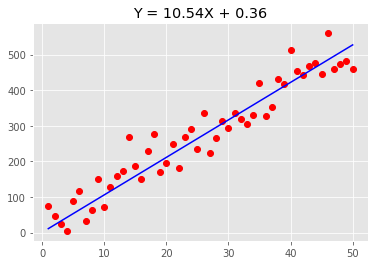

In [12]:
plt.plot(train_X, train_Y, 'ro')
pred_Y = np.multiply(train_X, learnt_W)+learnt_b
plt.plot(train_X, pred_Y, 'b')
plt.title("Y = {:0.2f}X + {:0.2f}".format(learnt_W[0, 0], learnt_b[0]))